# Milestone 3: Exploratory Data Analysis (EDA)

## 1. Group Members and Contributions

| Member Name | Student ID | Contribution |
|---|---|---|
| Ahmed AlSaad | 202432980 | Advanced and multivariate visualizations, correlation analysis, and interpretation of variable relationships. |
| Majed AlOwayyeidh | 202467820 | Dataset overview, variable identification, and statistical summaries for numeric and categorical variables. |
| Talal AlDakheel | 202467400 | Bivariate analysis related to churn, including comparisons between churn and contract type, internet service, payment method, and senior citizen status. |
| Rakan AlShalan | 202351430 | Data visualization for univariate analysis, including histograms, boxplots, and count plots. |
| Abdullah Alluqmani | 202257720 | Findings summary, notebook organization, formatting, proofreading, and integration of all sections into the final report. |

## Project Objective

The objective of this project is to perform exploratory data analysis on the Telco Customer Churn dataset in order to identify patterns, trends, and relationships associated with customer churn. This analysis will help reveal the most important variables affecting churn and support the selection of an appropriate predictive model in the next milestone.

In [37]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

#Colab path
df = pd.read_excel("/content/telco_churn_cleaned.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview

This section presents the structure of the dataset, the variable types, and the overall size of the data.

In [38]:
print("Shape of dataset:", df.shape)
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

Shape of dataset: (7043, 21)

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contrac

In [39]:
variable_info = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

variable_info

,Variable,Data Type,Unique Values
0,customerID,object,7043
1,gender,object,2
2,SeniorCitizen,int64,2
3,Partner,object,2
4,Dependents,object,2
5,tenure,int64,73
6,PhoneService,object,2
7,MultipleLines,object,3
8,InternetService,object,3
9,OnlineSecurity,object,3


### Dataset Overview Interpretation

The dataset contains customer-level information related to demographics, services subscribed to, billing information, and churn status. It includes both categorical and numerical variables, which makes it suitable for exploratory data analysis using statistical summaries and different types of visualizations.

The target variable in this project is **Churn**, which indicates whether a customer left the company or not.

In [40]:
# Drop customerID from analysis if present
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## 3. Statistical Summary

According to the milestone requirements, statistical summaries should be provided for both numerical and categorical variables. In this section, descriptive statistics are presented for all major variables in the dataset.

In [41]:
num_summary = df[numeric_cols].describe().T
num_summary["median"] = df[numeric_cols].median()
num_summary["skewness"] = df[numeric_cols].skew()
num_summary

,count,mean,std,min,25%,50%,75%,max,median,skewness
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00,0.00,1.833633
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,29.00,0.239540
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,70.35,-0.220524
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,1394.55,0.963235


In [42]:
cat_summary_list = []

for col in categorical_cols:
    mode_val = df[col].mode()[0] if not df[col].mode().empty else np.nan
    cat_summary_list.append({
        "Variable": col,
        "Unique Categories": df[col].nunique(),
        "Mode": mode_val,
        "Most Frequent Count": df[col].value_counts().iloc[0],
        "Most Frequent %": round(df[col].value_counts(normalize=True).iloc[0] * 100, 2)
    })

cat_summary = pd.DataFrame(cat_summary_list)
cat_summary

,Variable,Unique Categories,Mode,Most Frequent Count,Most Frequent %
0,gender,2,Male,3555,50.48
1,Partner,2,No,3641,51.70
2,Dependents,2,No,4933,70.04
3,PhoneService,2,Yes,6361,90.32
4,MultipleLines,3,No,3390,48.13
5,InternetService,3,Fiber optic,3096,43.96
6,OnlineSecurity,3,No,3498,49.67
7,OnlineBackup,3,No,3088,43.84
8,DeviceProtection,3,No,3095,43.94
9,TechSupport,3,No,3473,49.31


In [43]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    display(pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percentage": round(df[col].value_counts(normalize=True) * 100, 2)
    }))


===== gender =====


,Count,Percentage
gender,,
Male,3555,50.48
Female,3488,49.52



===== Partner =====


,Count,Percentage
Partner,,
No,3641,51.7
Yes,3402,48.3



===== Dependents =====


...

,Count,Percentage
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



===== PaymentMethod =====


,Count,Percentage
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61



===== Churn =====


,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


### Statistical Summary Interpretation

The statistical summary provides an overview of the central tendency, spread, and distribution of the numerical variables such as tenure, MonthlyCharges, and TotalCharges. In addition, the categorical summary shows the frequency distribution of variables such as Contract, InternetService, PaymentMethod, and Churn.

These summaries provide the foundation for identifying patterns and selecting the most relevant visualizations for the exploratory analysis.

## 4. Univariate Analysis

This section examines each variable individually to understand its distribution and general characteristics. Histograms and boxplots are used for numerical variables, while count plots are used for categorical variables.

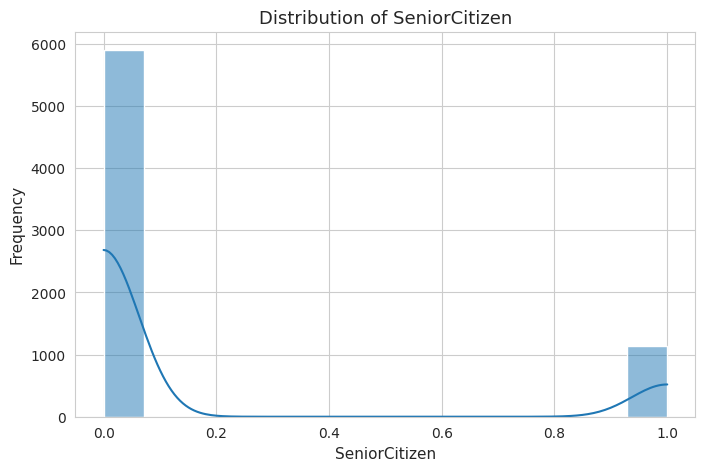

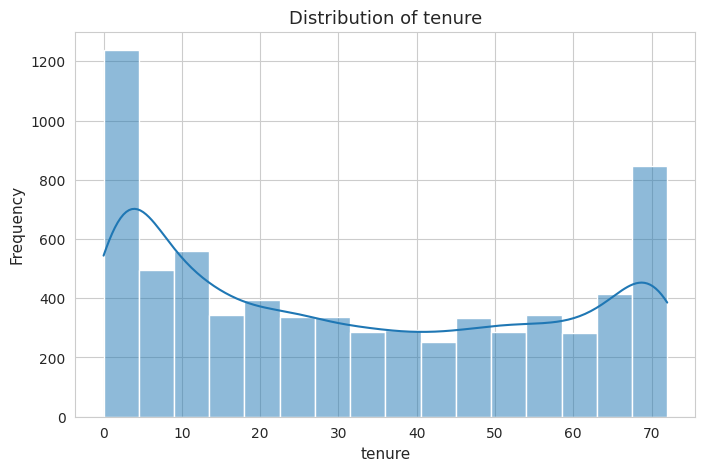

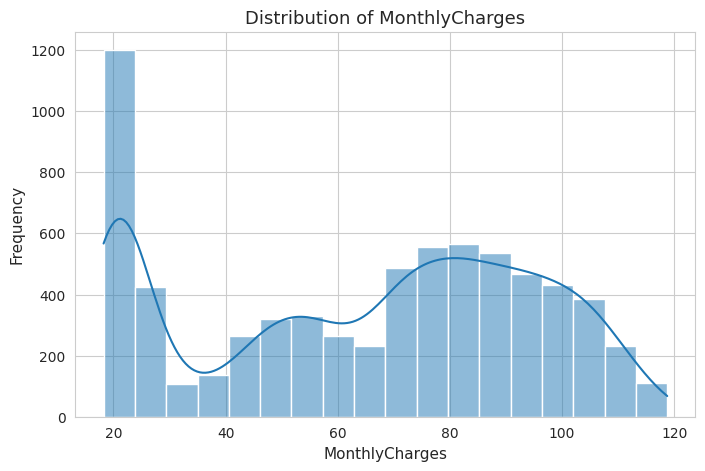

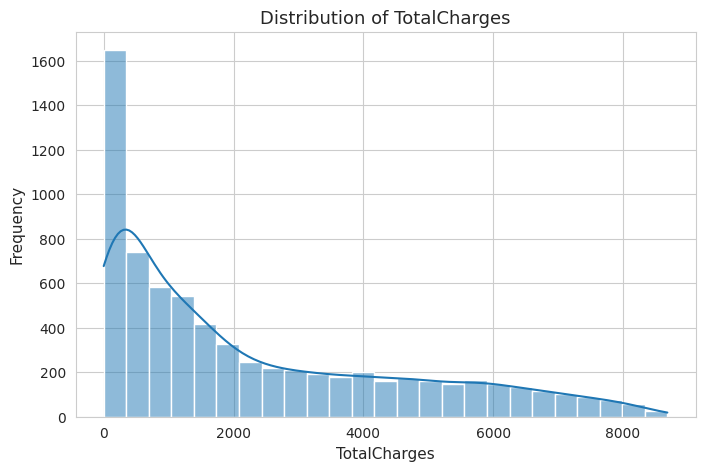

In [44]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

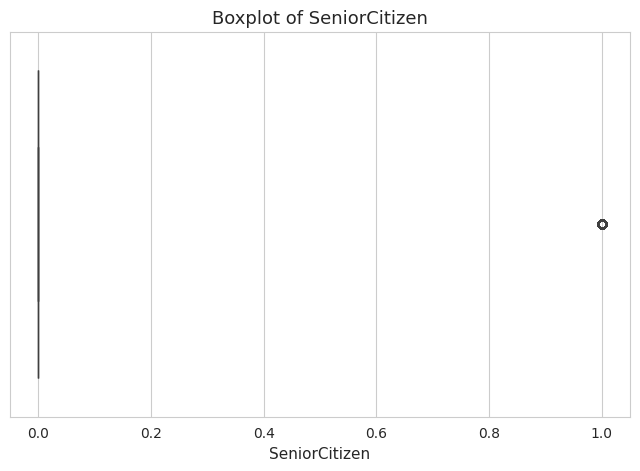

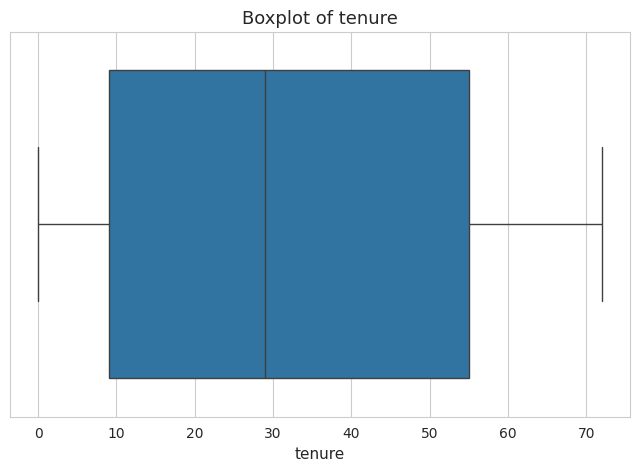

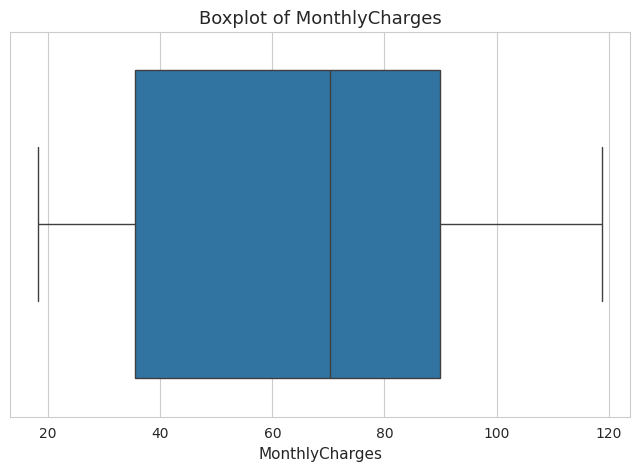

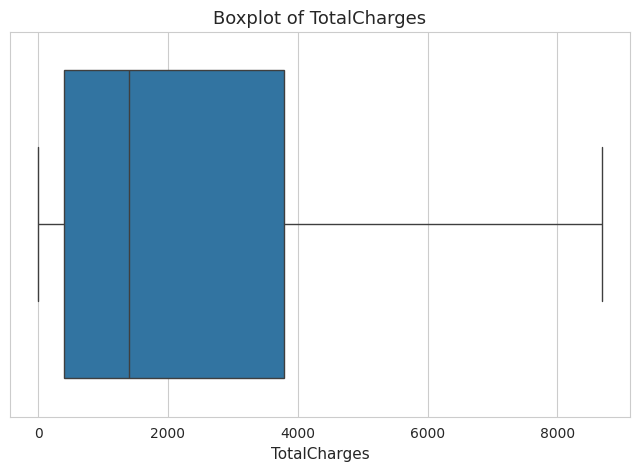

In [45]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

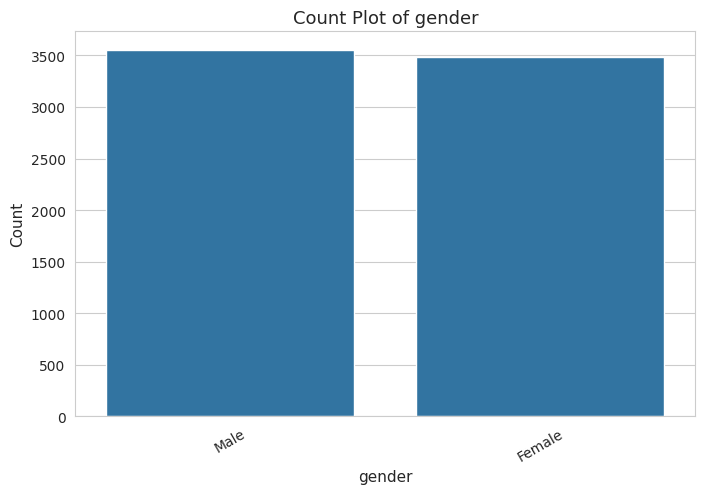

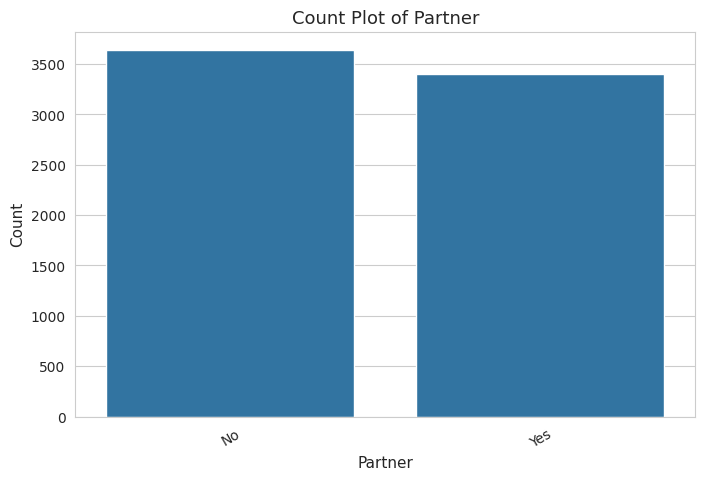

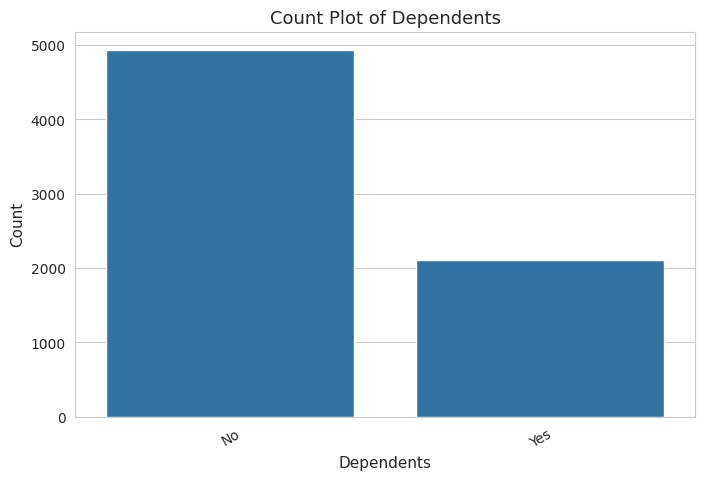

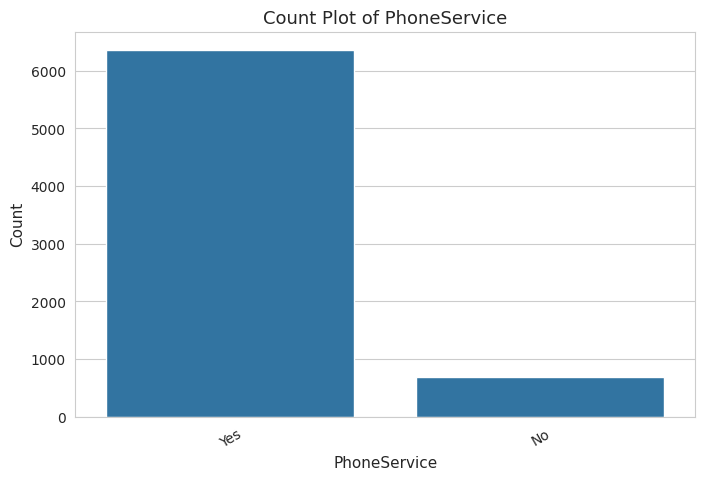

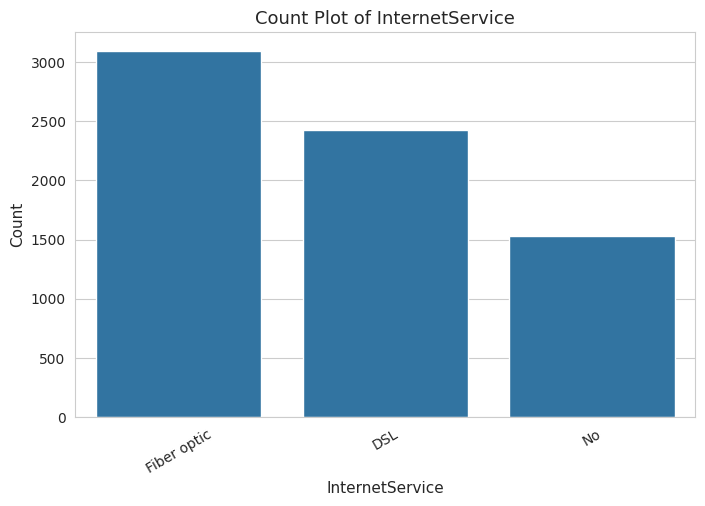

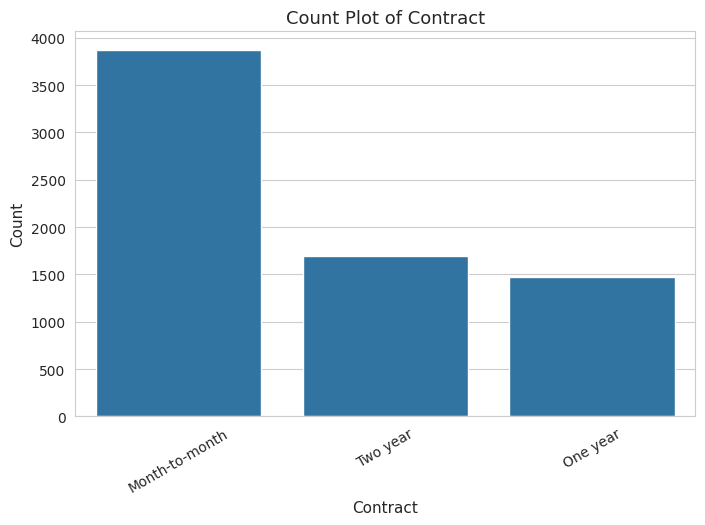

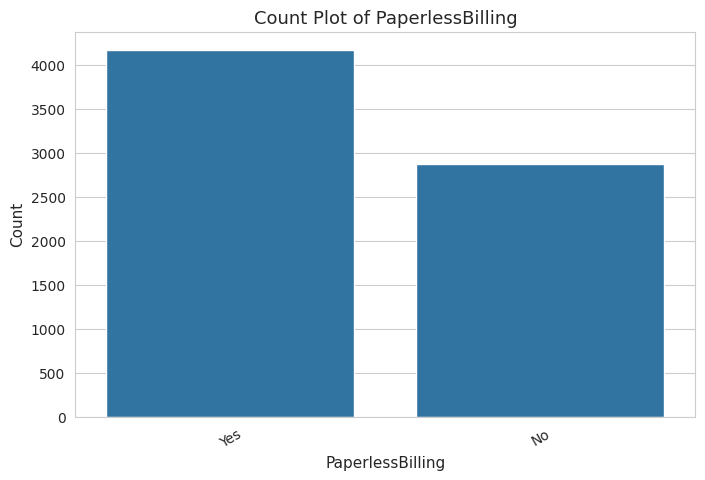

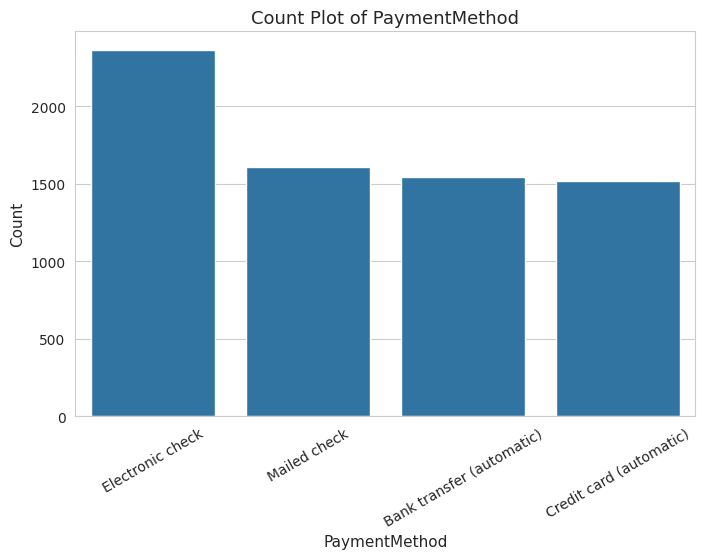

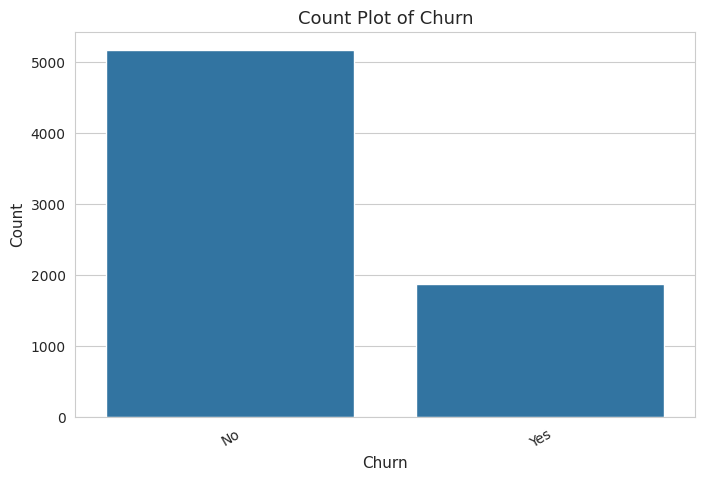

In [46]:
selected_cat_cols = [col for col in categorical_cols if col in [
    "Churn", "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract", "PaymentMethod",
    "PaperlessBilling"
]]

for col in selected_cat_cols:
    plt.figure(figsize=(8, 5))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

### Univariate Analysis Interpretation

The univariate analysis helps in understanding the overall distribution of both numerical and categorical variables. Histograms reveal the shape and spread of numerical variables, while boxplots highlight possible outliers. Count plots show the frequency of categories and help identify dominant patterns in service type, billing method, contract type, and churn status.

## 5. Bivariate Analysis

This section investigates the relationship between important variables and the target variable, **Churn**. For categorical variables, grouped count plots and normalized churn-rate tables are used. For numerical variables, boxplots are used to compare their distributions across churn categories.

In [47]:
# Standardize target if needed
if "Churn" in df.columns:
    df["Churn"] = df["Churn"].astype(str).str.strip()

In [48]:
bivariate_cat_cols = [col for col in [
    "Contract", "InternetService", "PaymentMethod",
    "SeniorCitizen", "Partner", "Dependents",
    "PaperlessBilling", "TechSupport", "OnlineSecurity"
] if col in df.columns]

for col in bivariate_cat_cols:
    print(f"\n===== {col} vs Churn =====")
    ctab = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    display(ctab.round(2))


===== Contract vs Churn =====


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



===== InternetService vs Churn =====


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40



===== PaymentMethod vs Churn =====


...

Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57



===== TechSupport vs Churn =====


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17



===== OnlineSecurity vs Churn =====


Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


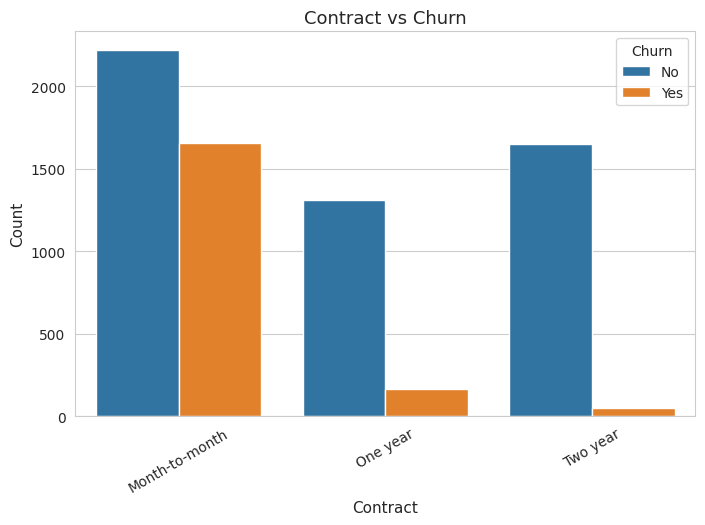

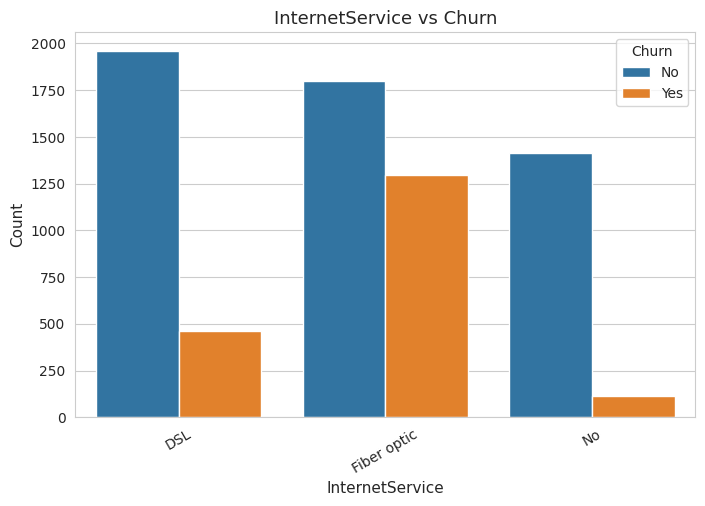

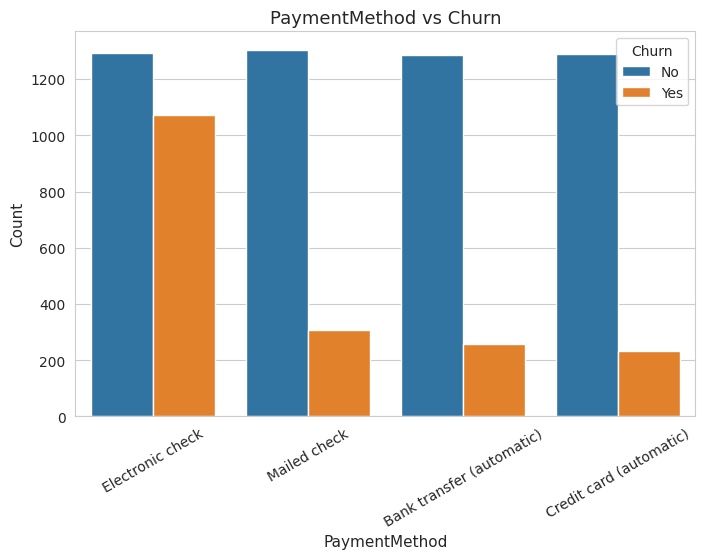

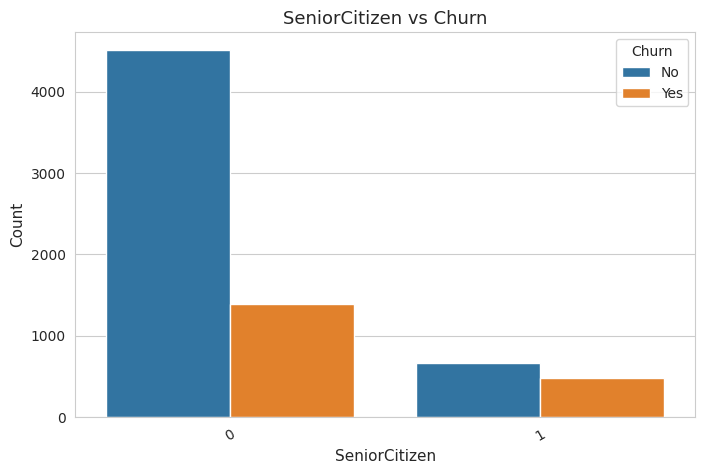

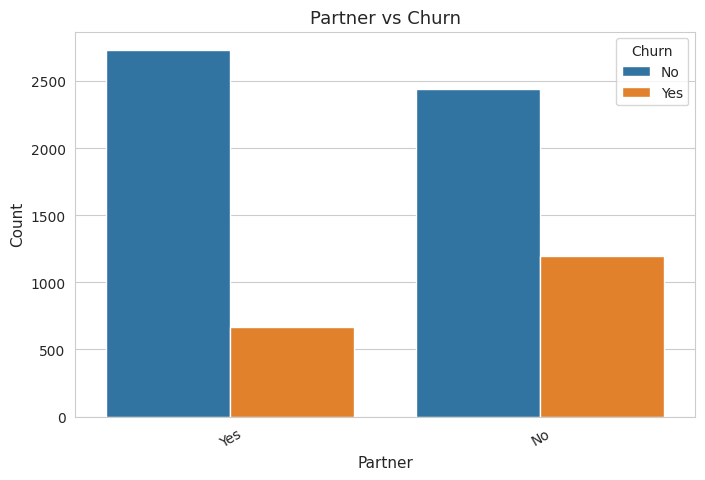

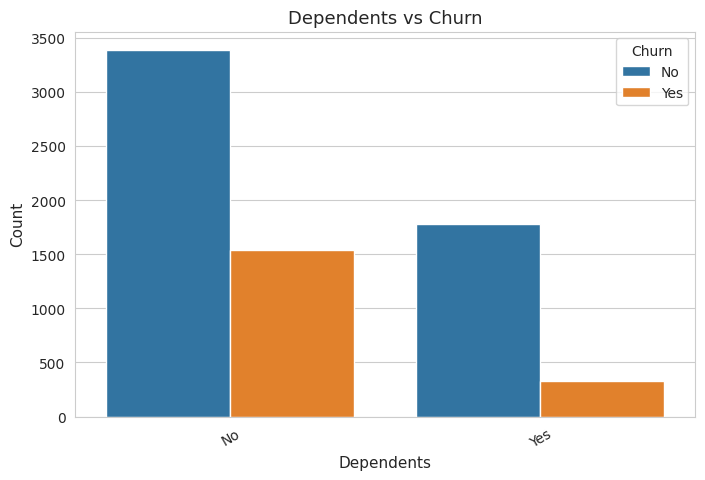

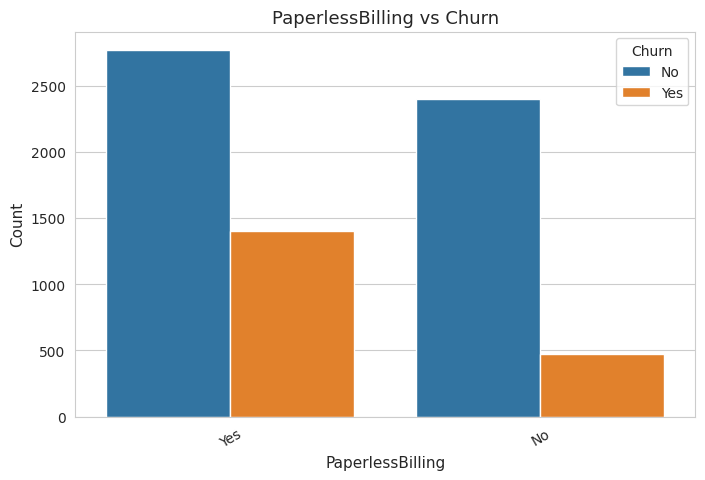

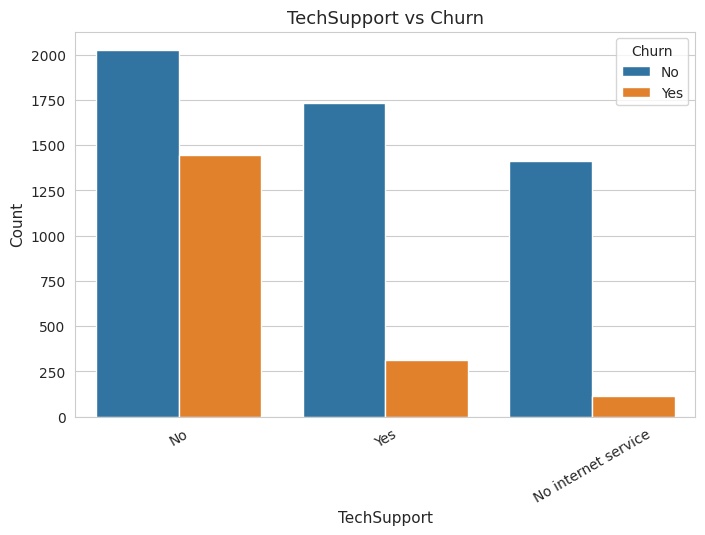

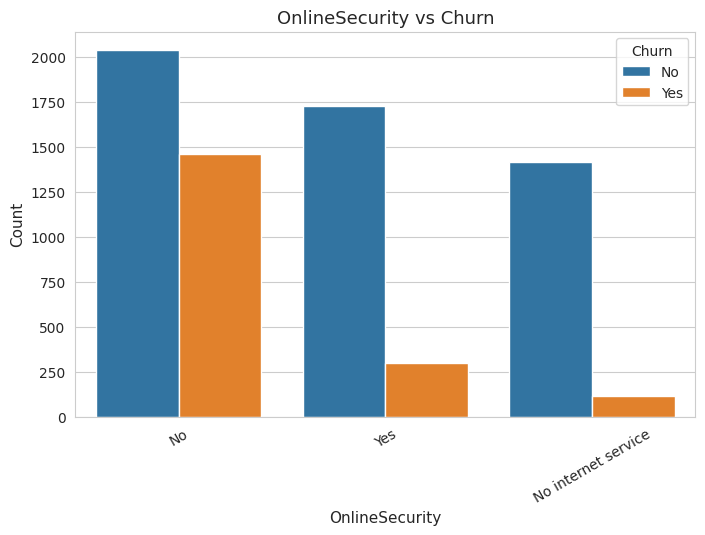

In [49]:
for col in bivariate_cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

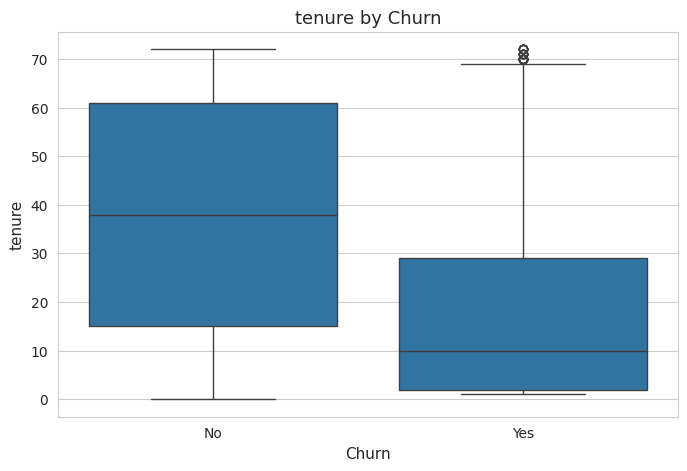

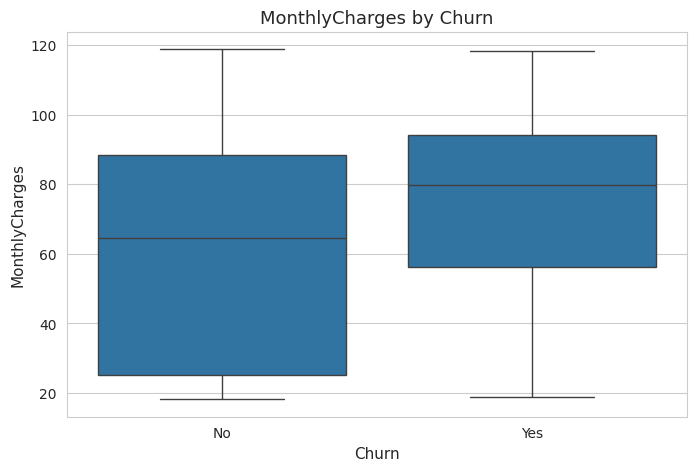

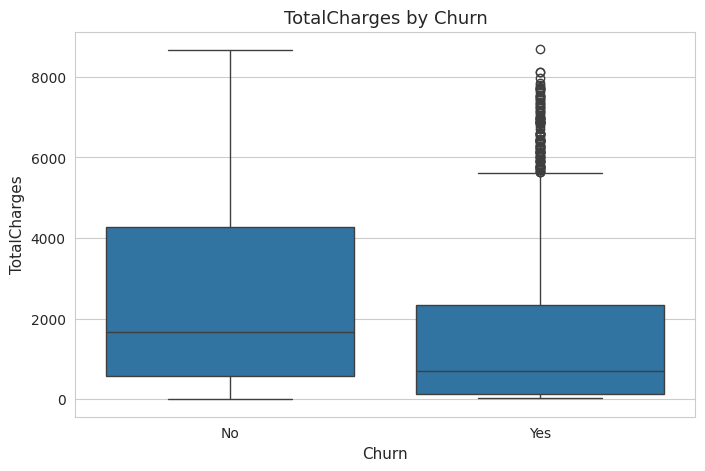

In [50]:
num_vs_churn = [col for col in ["tenure", "MonthlyCharges", "TotalCharges"] if col in df.columns]

for col in num_vs_churn:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [51]:
for col in num_vs_churn:
    print(f"\n===== {col} grouped by Churn =====")
    display(df.groupby("Churn")[col].describe().round(2))


===== tenure grouped by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0



===== MonthlyCharges grouped by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35



===== TotalCharges grouped by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.91,2329.95,0.00,572.9,1679.52,4262.85,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.5,703.55,2331.30,8684.80


### Bivariate Analysis Interpretation

The bivariate analysis compares customer churn with important service and account-related variables. Categorical comparisons help identify which groups have a higher churn rate, while numerical comparisons show whether variables such as tenure, MonthlyCharges, and TotalCharges differ between churned and non-churned customers.

These comparisons are important because they reveal the strongest candidate variables for the predictive modeling stage.

## 6. Advanced and Multivariate Analysis

This section explores relationships involving more than two variables. Correlation analysis and multivariate visualizations are used to identify deeper patterns in the data.

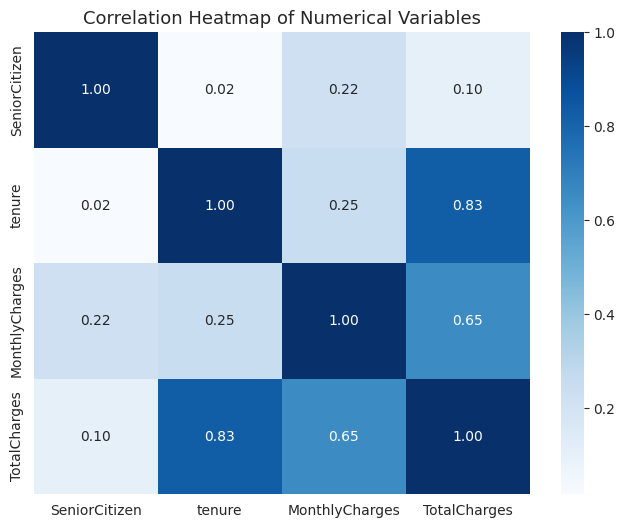

In [52]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation Heatmap of Numerical Variables")
    plt.show()

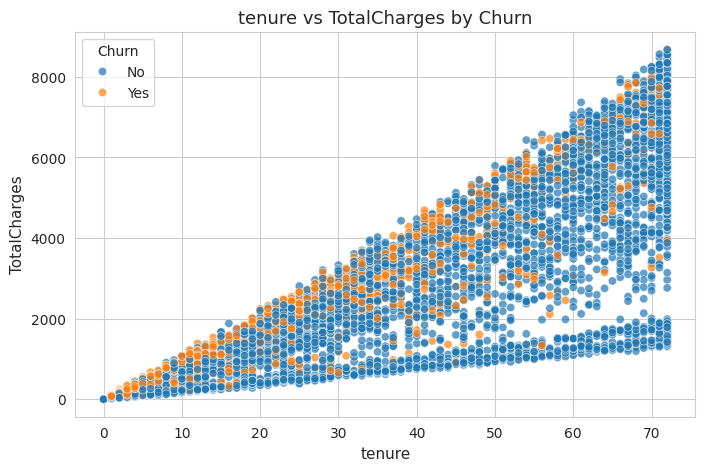

In [53]:
if all(col in df.columns for col in ["tenure", "TotalCharges", "Churn"]):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x="tenure", y="TotalCharges", hue="Churn", alpha=0.7)
    plt.title("tenure vs TotalCharges by Churn")
    plt.xlabel("tenure")
    plt.ylabel("TotalCharges")
    plt.show()

In [54]:
if all(col in df.columns for col in ["Contract", "InternetService", "Churn"]):
    churn_rate_ci = pd.crosstab(
        [df["Contract"], df["InternetService"]],
        df["Churn"],
        normalize="index"
    ) * 100

    display(churn_rate_ci.round(2))

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78

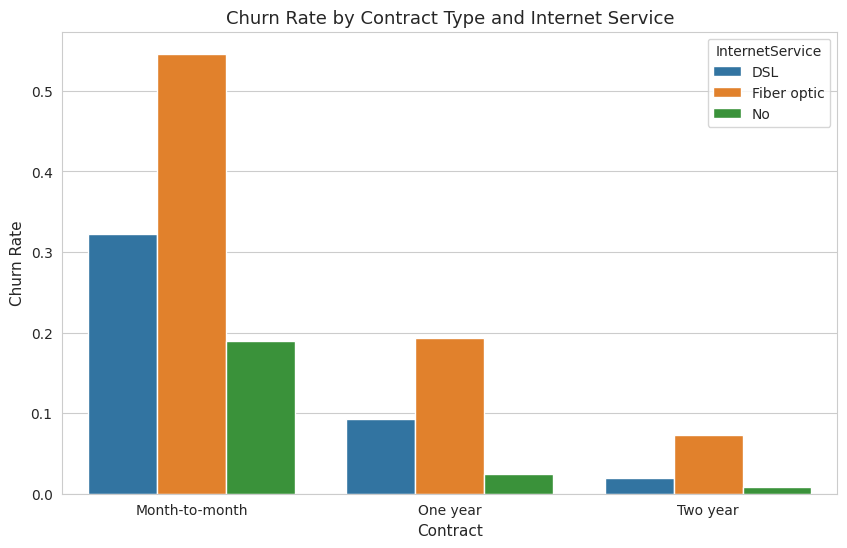

In [55]:
if all(col in df.columns for col in ["Contract", "InternetService", "Churn"]):
    plot_df = pd.crosstab(
        [df["Contract"], df["InternetService"]],
        df["Churn"],
        normalize="index"
    ).reset_index()

    if "Yes" in plot_df.columns:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=plot_df, x="Contract", y="Yes", hue="InternetService")
        plt.title("Churn Rate by Contract Type and Internet Service")
        plt.ylabel("Churn Rate")
        plt.xlabel("Contract")
        plt.show()

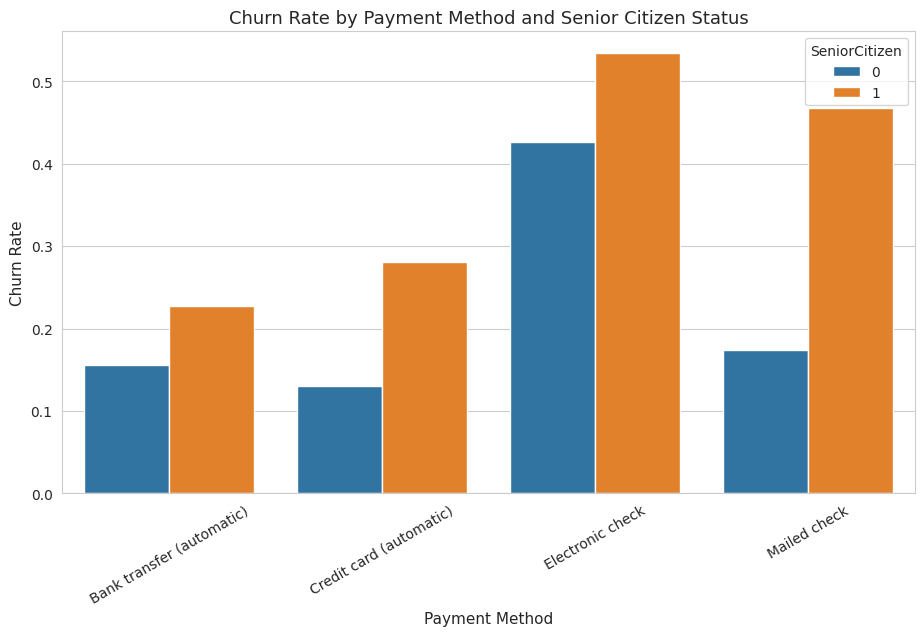

In [56]:
if all(col in df.columns for col in ["SeniorCitizen", "PaymentMethod", "Churn"]):
    plot_df2 = pd.crosstab(
        [df["SeniorCitizen"], df["PaymentMethod"]],
        df["Churn"],
        normalize="index"
    ).reset_index()

    if "Yes" in plot_df2.columns:
        plt.figure(figsize=(11, 6))
        sns.barplot(data=plot_df2, x="PaymentMethod", y="Yes", hue="SeniorCitizen")
        plt.title("Churn Rate by Payment Method and Senior Citizen Status")
        plt.ylabel("Churn Rate")
        plt.xlabel("Payment Method")
        plt.xticks(rotation=30)
        plt.show()

### Advanced and Multivariate Analysis Interpretation

The advanced visualizations provide a broader understanding of how variables interact together in relation to churn. The correlation heatmap summarizes the strength of relationships among numerical variables, while multivariate grouped plots help reveal combinations of customer characteristics that may be associated with higher churn rates.

These visualizations are useful because they move beyond simple one-variable and two-variable comparisons and provide richer insight into the structure of the data.

## 7. Relationship and Correlation Analysis

This section summarizes the most important relationships identified during the exploratory data analysis and highlights the variables that appear to be most strongly associated with churn.

In [57]:
# Encode churn for simple numeric correlation checks
df_corr = df.copy()

for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = df_corr[col].astype("category").cat.codes

corr_with_target = df_corr.corr(numeric_only=True)["Churn"].sort_values(ascending=False)
corr_with_target

,Churn
Churn,1.000000
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
PaymentMethod,0.107062
MultipleLines,0.038037
PhoneService,0.011942
gender,-0.008612
StreamingTV,-0.036581
StreamingMovies,-0.038492


### Relationship and Correlation Interpretation

The analysis indicates that several variables are associated with customer churn. Based on the visualizations and comparison tables, variables such as **Contract**, **InternetService**, **PaymentMethod**, **tenure**, **MonthlyCharges**, and **TotalCharges** should be examined carefully in the modeling phase.

The correlation results for numerical variables and the grouped churn-rate comparisons for categorical variables help identify which features are likely to have the strongest predictive value.

## 8. Key Findings

After performing the exploratory data analysis, the following major findings were observed:

1. Customers with certain contract types appear to have different churn rates.
2. Churn varies across different internet service categories.
3. Payment method may be associated with customer churn.
4. Numerical variables such as tenure, MonthlyCharges, and TotalCharges show different patterns between churned and non-churned customers.
5. Some combinations of variables in the multivariate analysis suggest stronger churn patterns than single-variable analysis alone.

These findings provide useful insight into customer behavior and will support the selection of a suitable classification model in the next milestone.

## 9. Conclusion

This milestone focused on performing exploratory data analysis on the Telco Customer Churn dataset. Statistical summaries, univariate plots, bivariate plots, advanced visualizations, and relationship analysis were used to explore the dataset and identify important churn-related patterns.

The results of this exploratory phase provide a strong foundation for the next step of the data analytics lifecycle, which is model building and evaluation. Based on the nature of the target variable, a classification model is expected to be the most suitable choice for the next milestone.

In [58]:
print("Dataset shape:", df.shape)
print("Number of numeric variables:", len(numeric_cols))
print("Number of categorical variables:", len(categorical_cols))
print("Target distribution:\n")
display(df["Churn"].value_counts(normalize=True).mul(100).round(2).rename("Percentage"))

Dataset shape: (7043, 20)
Number of numeric variables: 4
Number of categorical variables: 16
Target distribution:



,Percentage
Churn,
No,73.46
Yes,26.54
